<a href="https://colab.research.google.com/github/ACRivera1/data-quality-engine/blob/main/Workplace_Diversity_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏢 Workplace Diversity Analysis
### Using Data Science to Detect Pay Inequity & Unconscious Bias

---

**Business Goal:** The Head of HR wants to know — *are all employees treated fairly?*  
We will use real company data to:
1. **Classify** every employee by organizational level (IC → CEO)
2. **Count** how many people each employee manages (direct + indirect)
3. **Predict** salaries with a machine learning model
4. **Analyze** what drives pay — and whether gender plays an unfair role

---

## 📋 Table of Contents
- [Section 1: Environment Setup & Installs](#section-1)
- [Section 2: Load & Explore the Data](#section-2)
- [Section 3: Task 1 — Classify Employee Levels](#section-3)
- [Section 4: Task 2 — Count People Managed](#section-4)
- [Section 5: Task 3 — Predict Salaries with ML](#section-5)
- [Section 6: Task 4 — Salary Fairness Analysis](#section-6)
- [Section 7: HR Recommendations](#section-7)


---
<a id='section-1'></a>
## Section 1: Environment Setup & Installs

Before anything else, we need to make sure all required Python libraries are installed.
Run the cell below **once** when setting up a new machine or environment.

### 📦 Libraries We Are Using

| Library | Purpose |
|---|---|
| `pandas` | Load, clean, and manipulate tabular data (like Excel but in Python) |
| `numpy` | Fast numerical computations and array math |
| `matplotlib` | Create charts and visualizations |
| `seaborn` | Beautiful statistical charts built on top of matplotlib |
| `scikit-learn` | Machine learning — model training, evaluation, encoding |
| `scipy` | Statistical tests (t-test to check if salary gaps are real) |


In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# INSTALL LIBRARIES
# ─────────────────────────────────────────────────────────────────────────────
# The exclamation mark (!) means: run this as a terminal command, not Python.
# pip is Python's package installer.
# These are all standard data science libraries — safe and widely used.

!pip install pandas numpy matplotlib seaborn scikit-learn scipy

print("✅ All libraries installed!")


✅ All libraries installed!


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORT LIBRARIES INTO THIS NOTEBOOK
# ─────────────────────────────────────────────────────────────────────────────
# Installing a library puts it on your computer.
# 'import' loads it into THIS notebook session so we can use it.

import warnings                              # suppress minor warnings we don't need to see
warnings.filterwarnings('ignore')           # cleaner output

# ── Data handling ─────────────────────────────────────────────────────────────
import pandas as pd                          # pd is the universal shorthand for pandas
import numpy as np                           # np is the universal shorthand for numpy

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt             # plt is the standard shorthand
import seaborn as sns                       # sns is the standard shorthand

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor    # our main ML model
from sklearn.linear_model import LinearRegression    # simpler baseline model
from sklearn.model_selection import train_test_split  # split data for training/testing
from sklearn.metrics import (                         # tools to measure model accuracy
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ── Statistics ────────────────────────────────────────────────────────────────
from scipy import stats                      # for t-test (checking if a gap is real)

# ── Python standard library ───────────────────────────────────────────────────
from collections import deque               # efficient queue for tree traversal
import sys                                   # system settings (we'll raise recursion limit)

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 25)    # show up to 25 columns in any DataFrame
pd.set_option('display.float_format', '{:,.2f}'.format)  # commas in numbers, 2 decimals
sns.set_theme(style='whitegrid', palette='muted')        # clean, professional chart style
# %matplotlib inline renders plots inside the notebook (must be on its own line — no inline comments allowed on magic commands)
%matplotlib inline

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


---
<a id='section-2'></a>
## Section 2: Load & Explore the Data

We have **two CSV files** (CSV = Comma-Separated Values, a plain-text spreadsheet format):

### 📁 File 1: `company_hierarchy.csv`
| Column | Description |
|---|---|
| `employee_id` | Unique number identifying each employee |
| `boss_id` | The `employee_id` of their direct manager (NaN for the CEO — no boss!) |
| `dept` | Their department: Engineering, Marketing, Sales, HR, or CEO |

### 📁 File 2: `employee.csv`
| Column | Description |
|---|---|
| `employee_id` | Same unique ID — this is how we **link** the two tables |
| `signing_bonus` | Did they get a signing bonus when hired? (1=Yes, 0=No) |
| `salary` | Current annual salary in USD |
| `degree_level` | Highest education: High_School, Bachelor, Master, or PhD |
| `sex` | Gender: M or F |
| `yrs_experience` | Years of professional work experience |


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# LOAD THE CSV FILES
# ─────────────────────────────────────────────────────────────────────────────
# pd.read_csv() reads a CSV file from disk and creates a DataFrame.
# A DataFrame is like a spreadsheet in Python — rows and columns.
#
# ⚠️  Make sure your CSV files are in the SAME FOLDER as this notebook.
#     If they are in a subfolder, e.g. 'data/', use: 'data/company_hierarchy.csv'

hierarchy = pd.read_csv('company_hierarchy.csv')   # org chart: who reports to whom
employee  = pd.read_csv('employee.csv')            # personal details: salary, degree, etc.

print(f"Hierarchy table  → {hierarchy.shape[0]:,} rows, {hierarchy.shape[1]} columns")
print(f"Employee  table  → {employee.shape[0]:,} rows, {employee.shape[1]} columns")


Hierarchy table  → 10,000 rows, 3 columns
Employee  table  → 10,000 rows, 6 columns


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# PEEK AT THE DATA — hierarchy table
# ─────────────────────────────────────────────────────────────────────────────
# .head(n) shows the first n rows. Default is 5.
# This is always the first thing to do — never assume what the data looks like!

print("=== HIERARCHY TABLE (first 5 rows) ===")
display(hierarchy.head())               # 'display()' renders a prettier table in Jupyter


=== HIERARCHY TABLE (first 5 rows) ===


,employee_id,boss_id,dept
0,46456,"175,361.00",sales
1,104708,"29,733.00",HR
2,120853,"41,991.00",sales
3,142630,"171,266.00",HR
4,72711,"198,240.00",sales


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# PEEK AT THE DATA — employee table
# ─────────────────────────────────────────────────────────────────────────────
print("=== EMPLOYEE TABLE (first 5 rows) ===")
display(employee.head())


=== EMPLOYEE TABLE (first 5 rows) ===


,employee_id,signing_bonus,salary,degree_level,sex,yrs_experience
0,138719,0,"273,000.00",Master,M,2
1,3192,0,"301,000.00",Bachelor,F,1
2,114657,0,"261,000.00",Master,F,2
3,29039,0,"86,000.00",High_School,F,4
4,118607,0,"126,000.00",Bachelor,F,3


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# DATA TYPES AND MISSING VALUES
# ─────────────────────────────────────────────────────────────────────────────
# .info() is one of the most useful first-look commands.
# It shows:
#   • Each column's name
#   • How many non-null (non-missing) values exist
#   • The data type (int=whole number, float=decimal, object=text)

print("=== HIERARCHY TABLE INFO ===")
hierarchy.info()
print()

print("=== EMPLOYEE TABLE INFO ===")
employee.info()


=== HIERARCHY TABLE INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   employee_id  10000 non-null  int64  
 1   boss_id      9999 non-null   float64
 2   dept         10000 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 234.5+ KB

=== EMPLOYEE TABLE INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   employee_id     10000 non-null  int64  
 1   signing_bonus   10000 non-null  int64  
 2   salary          10000 non-null  float64
 3   degree_level    10000 non-null  object 
 4   sex             10000 non-null  object 
 5   yrs_experience  10000 non-null  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 468.9+ KB


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CHECK FOR MISSING VALUES EXPLICITLY
# ─────────────────────────────────────────────────────────────────────────────
# .isnull() returns True where a value is missing.
# .sum() counts the Trues per column.
# We expect exactly 1 missing boss_id — that's the CEO (who has no boss).

print("Missing values in HIERARCHY table:")
print(hierarchy.isnull().sum())
print()
print("Missing values in EMPLOYEE table:")
print(employee.isnull().sum())
print()
print("👆 1 missing boss_id is expected — that row is the CEO!")


Missing values in HIERARCHY table:
employee_id    0
boss_id        1
dept           0
dtype: int64

Missing values in EMPLOYEE table:
employee_id       0
signing_bonus     0
salary            0
degree_level      0
sex               0
yrs_experience    0
dtype: int64

👆 1 missing boss_id is expected — that row is the CEO!


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# DESCRIPTIVE STATISTICS FOR NUMERIC COLUMNS
# ─────────────────────────────────────────────────────────────────────────────
# .describe() computes 8 summary statistics in one shot:
#   count  = number of non-null values
#   mean   = average
#   std    = standard deviation (spread around the mean)
#   min    = smallest value
#   25%    = 1st quartile (25% of values are below this)
#   50%    = median (middle value)
#   75%    = 3rd quartile
#   max    = largest value

print("=== EMPLOYEE TABLE — Numeric Summary ===")
display(employee.describe())


=== EMPLOYEE TABLE — Numeric Summary ===


,employee_id,signing_bonus,salary,yrs_experience
count,"10,000.00","10,000.00","10,000.00","10,000.00"
mean,"100,001.86",0.30,"189,111.80",3.88
std,"57,500.49",0.46,"88,973.80",3.11
min,40.00,0.00,"60,000.00",1.00
25%,"50,574.50",0.00,"110,000.00",2.00
50%,"99,244.50",0.00,"182,000.00",3.00
75%,"149,748.50",1.00,"255,000.00",5.00
max,"199,956.00",1.00,"700,000.00",34.00


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# EXPLORE CATEGORICAL COLUMNS
# ─────────────────────────────────────────────────────────────────────────────
# .value_counts() counts how many times each unique value appears.
# This tells us the breakdown of departments, degrees, and gender.

print("Departments (hierarchy):")
print(hierarchy['dept'].value_counts())
print()

print("Degree levels (employee):")
print(employee['degree_level'].value_counts())
print()

print("Sex distribution (employee):")
print(employee['sex'].value_counts())
print()

print("Signing bonus distribution (employee):")
print(employee['signing_bonus'].value_counts())


Departments (hierarchy):
dept
sales          3599
engineering    2696
marketing      2010
HR             1694
CEO               1
Name: count, dtype: int64

Degree levels (employee):
degree_level
PhD            2822
Master         2786
Bachelor       2735
High_School    1657
Name: count, dtype: int64

Sex distribution (employee):
sex
M    6439
F    3561
Name: count, dtype: int64

Signing bonus distribution (employee):
signing_bonus
0    6986
1    3014
Name: count, dtype: int64


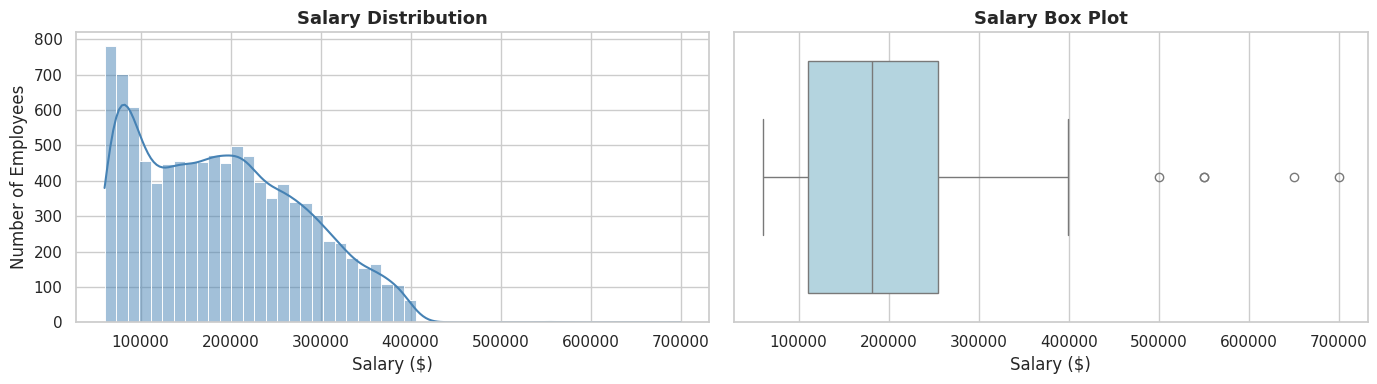

Min salary : $60,000
Mean salary: $189,112
Max salary : $700,000


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# SALARY DISTRIBUTION — Histogram
# ─────────────────────────────────────────────────────────────────────────────
# Before modeling, it is important to VISUALISE the target variable (salary).
# A histogram shows how values are distributed across buckets (bins).
# A KDE (Kernel Density Estimate) is the smooth curve version.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: Histogram with KDE
sns.histplot(employee['salary'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Salary Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Salary ($)')
axes[0].set_ylabel('Number of Employees')

# Right: Box plot — shows median, quartiles, and outliers
# The box spans Q1-Q3 (the 'middle 50%'); the line inside is the median.
# Points beyond the whiskers are potential outliers.
sns.boxplot(x=employee['salary'], ax=axes[1], color='lightblue')
axes[1].set_title('Salary Box Plot', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Salary ($)')

plt.tight_layout()   # auto-adjust spacing so plots don't overlap
plt.show()

print(f"Min salary : ${employee['salary'].min():,.0f}")
print(f"Mean salary: ${employee['salary'].mean():,.0f}")
print(f"Max salary : ${employee['salary'].max():,.0f}")


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# MERGE THE TWO TABLES
# ─────────────────────────────────────────────────────────────────────────────
# Our data is split across two tables. We JOIN them using the shared key:
# employee_id (present in BOTH tables).
#
# pd.merge() is like SQL's JOIN command.
# how='inner' means: keep only rows where employee_id appears in BOTH tables.
# (An 'outer' join would keep ALL rows from both, filling gaps with NaN.)

df = pd.merge(
    hierarchy,          # left table
    employee,           # right table
    on='employee_id',   # the column to match on
    how='inner'         # only rows present in both tables
)

print(f"Merged DataFrame shape: {df.shape}")
print(f"(We expect 10,000 rows if all IDs match perfectly)")
print()
display(df.head())


Merged DataFrame shape: (10000, 8)
(We expect 10,000 rows if all IDs match perfectly)



,employee_id,boss_id,dept,signing_bonus,salary,degree_level,sex,yrs_experience
0,46456,"175,361.00",sales,0,"213,000.00",Bachelor,M,5
1,104708,"29,733.00",HR,0,"79,000.00",Bachelor,F,3
2,120853,"41,991.00",sales,0,"199,000.00",High_School,M,5
3,142630,"171,266.00",HR,0,"143,000.00",PhD,F,13
4,72711,"198,240.00",sales,0,"235,000.00",Master,M,1


---
<a id='section-3'></a>
## Section 3: Task 1 — Classify Employee Levels

### 🏗️ The Hierarchy
The company has 6 levels. From **most senior** to **most junior**:

```
  [CEO]          ← 1 person, no boss
    │
  [Executives]   ← direct reports of the CEO
    │
  [Vice Presidents] ← direct reports of Executives
    │
  [Directors]    ← direct reports of VPs
    │
  [Middle Managers] ← direct reports of Directors
    │
  [ICs]          ← Individual Contributors, direct reports of MMs
```

### 🧠 Algorithm: Breadth-First Search (BFS)
We need to find the *depth* of each employee in the tree (how many levels below the CEO).

**BFS** processes a tree **level by level** — perfect for our use case:
- Start at the CEO (depth = 0)
- Visit all CEOs direct reports (depth = 1 → Executives)
- Then their reports (depth = 2 → VPs)… and so on.

Think of it like ripples spreading outward from a stone dropped in water — each ring is one level.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 3.1 — Identify the CEO
# ─────────────────────────────────────────────────────────────────────────────
# The CEO is the ONLY employee with a missing boss_id.
# Everyone else has a boss; the CEO reports to no one.
#
# df['boss_id'].isnull()  → creates a True/False mask
# df[ mask ]              → keeps only rows where mask is True
# .values[0]              → pull out the first (only) value as a raw number
# int(...)                → convert from float (60.0) to integer (60)

ceo_row = df[df['boss_id'].isnull()]            # filter: only row with no boss
ceo_id  = int(ceo_row['employee_id'].values[0]) # extract CEO's employee_id

print(f"CEO employee_id: {ceo_id}")
print()
print("CEO's full data row:")
display(ceo_row)


CEO employee_id: 61554

CEO's full data row:


,employee_id,boss_id,dept,signing_bonus,salary,degree_level,sex,yrs_experience
2427,61554,NaN,CEO,1,"700,000.00",PhD,M,7


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 3.2 — Build a 'children map': boss → set of direct reports
# ─────────────────────────────────────────────────────────────────────────────
# We need to quickly answer: "Who does employee X directly manage?"
# We precompute this as a dictionary for fast O(1) lookups.
#
# Example structure:
#   { 61554: {101, 202, 303},    ← CEO directly manages employees 101, 202, 303
#     101:   {404, 505},         ← Employee 101 manages 404 and 505
#     ... }
#
# Steps:
#   1. .dropna(subset=['boss_id'])  → remove CEO row (boss_id=NaN would crash groupby)
#   2. .groupby('boss_id')         → group rows by the boss
#   3. ['employee_id'].apply(set)  → collect each boss's direct reports as a Python set
#   4. .to_dict()                  → convert to a plain Python dictionary

children_map = (
    df.dropna(subset=['boss_id'])           # ignore CEO (they have no boss in the boss_id col)
    .groupby('boss_id')['employee_id']      # for each boss, look at their employees
    .apply(set)                             # collect employee_ids as a set
    .to_dict()                              # → {boss_id: {child_ids}}
)

print(f"Number of managers in the map: {len(children_map)}")
print(f"CEO's direct reports (Executives): {len(children_map.get(ceo_id, set()))} people")


Number of managers in the map: 999
CEO's direct reports (Executives): 4 people


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 3.3 — Breadth-First Search (BFS) to assign depth levels
# ─────────────────────────────────────────────────────────────────────────────
# BFS uses a QUEUE (First In, First Out) — like a checkout line at a store.
# We start with the CEO in the queue.
# Each iteration: take the front person, record their depth, add their children.
#
# deque (double-ended queue) is Python's built-in efficient queue.
# .popleft() removes from the FRONT (O(1)) — much faster than list.pop(0).
#
# Depth meaning:
#   0 = CEO, 1 = Executive, 2 = VP, 3 = Director, 4 = Middle Manager, 5 = IC

depth_to_level = {         # translate numeric depth to human-readable level name
    0: 'CEO',
    1: 'E',               # Executive
    2: 'VP',              # Vice President
    3: 'D',               # Director
    4: 'MM',              # Middle Manager
    5: 'IC',              # Individual Contributor
}

levels_map   = {}                          # will store {employee_id: level_name}
queue        = deque([(ceo_id, 0)])        # start queue: CEO at depth 0

while queue:                               # keep going until the queue is empty
    emp_id, depth = queue.popleft()       # take the FRONT item from the queue
    level_name    = depth_to_level.get(depth, 'IC')  # map depth → level name
    levels_map[emp_id] = level_name       # record this employee's level

    for child_id in children_map.get(emp_id, set()):  # loop over direct reports
        queue.append((child_id, depth + 1))           # add child one level deeper

# .map() replaces each employee_id in the column with its level name
df['level'] = df['employee_id'].map(levels_map)

print("✅ BFS complete. Level assignments done.")
print()
print("Employee count at each level:")
print(df['level'].value_counts().reindex(['CEO','E','VP','D','MM','IC']))


✅ BFS complete. Level assignments done.

Employee count at each level:
level
CEO       1
E         4
VP       35
D       160
MM      800
IC     9000
Name: count, dtype: int64


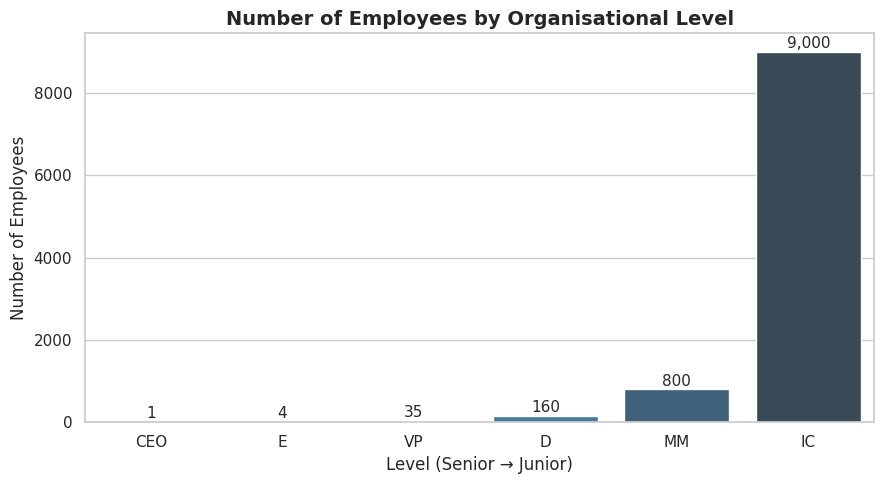


📌 Insight: This is a classic corporate pyramid — thousands of ICs, very few leaders.


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 3.4 — Visualise the level distribution
# ─────────────────────────────────────────────────────────────────────────────
# A count plot (bar chart of frequencies) shows the organisational pyramid.
# We expect many ICs at the bottom and very few Executives/CEO at the top.

level_order = ['CEO', 'E', 'VP', 'D', 'MM', 'IC']   # senior → junior order

plt.figure(figsize=(9, 5))
ax = sns.countplot(
    data=df,
    x='level',
    order=level_order,
    palette='Blues_d'          # darker blue = more common level
)

# Add the actual count number on top of each bar
for bar in ax.patches:
    height = int(bar.get_height())
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # x position: centre of bar
        height + 20,                          # y position: just above bar
        f'{height:,}',                        # label: number with comma separator
        ha='center', va='bottom', fontsize=11
    )

ax.set_title('Number of Employees by Organisational Level', fontsize=14, fontweight='bold')
ax.set_xlabel('Level (Senior → Junior)')
ax.set_ylabel('Number of Employees')
plt.tight_layout()
plt.show()

print("\n📌 Insight: This is a classic corporate pyramid — thousands of ICs, very few leaders.")


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 3.5 — Preview the result: first 10 rows with level assigned
# ─────────────────────────────────────────────────────────────────────────────
display(df[['employee_id', 'boss_id', 'dept', 'level', 'sex', 'salary']].head(10))


,employee_id,boss_id,dept,level,sex,salary
0,46456,"175,361.00",sales,IC,M,"213,000.00"
1,104708,"29,733.00",HR,IC,F,"79,000.00"
2,120853,"41,991.00",sales,IC,M,"199,000.00"
3,142630,"171,266.00",HR,MM,F,"143,000.00"
4,72711,"198,240.00",sales,IC,M,"235,000.00"
5,61704,"53,109.00",sales,IC,M,"196,000.00"
6,153072,"67,178.00",HR,IC,M,"99,000.00"
7,58903,"150,290.00",HR,IC,M,"78,000.00"
8,166034,"116,750.00",engineering,IC,M,"379,000.00"
9,54819,"182,038.00",sales,IC,F,"249,000.00"


---
<a id='section-4'></a>
## Section 4: Task 2 — Count Total People Managed

### 📐 What Does 'Total Managed' Mean?
It's not just direct reports — it's **everyone below you** in the org chart.

**Example:**  
John → directly manages Alice and Bob  
Alice → manages 5 people  
Bob → manages 5 people  
→ John manages: Alice + Bob + Alice's 5 + Bob's 5 = **12 people**

### 🔁 Algorithm: Recursive DFS (Depth-First Search)
We use **recursion** — a function that calls itself.

```
count_managed(emp):
   if emp has no reports → return 0
   else → return (number of direct reports) + sum(count_managed(each report))
```

The function digs all the way down to the ICs first, then builds the count *back up*.
This is called **post-order traversal** — process children before the parent.


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4.1 — Recursive function to count total managed employees
# ─────────────────────────────────────────────────────────────────────────────
# Why raise the recursion limit?
# Python limits how deeply functions can call themselves (default=1000).
# Our org chart is only 5 levels deep, but we have 10,000 nodes,
# so we raise the limit as a safety measure.

sys.setrecursionlimit(20000)   # allow up to 20,000 nested function calls

total_managed = {}             # CACHE: stores results we've already computed
                               # so we don't recalculate the same subtree twice

def count_managed(emp_id):
    """
    Recursively count ALL employees below emp_id (direct + indirect).

    Parameters:
        emp_id (int): The employee whose managed count we want.

    Returns:
        int: Total number of people managed (0 for ICs).
    """
    # Memoisation: if we've computed this before, return the cached result
    if emp_id in total_managed:
        return total_managed[emp_id]

    # Get this employee's direct reports
    direct_reports = children_map.get(emp_id, set())

    # BASE CASE: no direct reports → this is an IC, manages nobody
    if not direct_reports:
        total_managed[emp_id] = 0
        return 0

    # RECURSIVE CASE:
    # = (number of direct reports)
    # + (sum of how many each direct report manages)
    count = len(direct_reports) + sum(count_managed(child) for child in direct_reports)

    total_managed[emp_id] = count   # store in cache before returning
    return count


# Kick off the recursion from the CEO — this will cascade through all 10,000 employees
count_managed(ceo_id)

print(f"✅ Computed managed counts for {len(total_managed):,} employees.")


✅ Computed managed counts for 10,000 employees.


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4.2 — Add 'total_managed' column to the DataFrame
# ─────────────────────────────────────────────────────────────────────────────
# .map() replaces each employee_id with its pre-computed count from our cache dict.
# .fillna(0) handles any employee not in the dict (shouldn't happen, but safe).
# .astype(int) converts from float to integer (no decimals needed for a count).

df['total_managed'] = (
    df['employee_id']
    .map(total_managed)    # look up each employee_id in our cache
    .fillna(0)             # anyone not found → 0 (IC)
    .astype(int)           # convert to integer
)

# ── Sanity check ──────────────────────────────────────────────────────────────
# The CEO should manage 9,999 employees (everyone except themselves).
ceo_managed = df[df['employee_id'] == ceo_id][['employee_id', 'level', 'total_managed']]
print("CEO's total managed count:")
display(ceo_managed)

print()
# ICs should manage 0
ic_sample = df[df['level'] == 'IC'][['employee_id', 'level', 'total_managed']].head(3)
print("Sample IC rows (should be 0):")
display(ic_sample)


CEO's total managed count:


,employee_id,level,total_managed
2427,61554,CEO,9999



Sample IC rows (should be 0):


,employee_id,level,total_managed
0,46456,IC,0
1,104708,IC,0
2,120853,IC,0


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4.3 — Summary statistics by level
# ─────────────────────────────────────────────────────────────────────────────
# We group by level and compute mean, median, min, and max managed counts.
# This is a great sanity check: the numbers should get smaller as we go down.

summary = (
    df.groupby('level')['total_managed']
    .agg(['mean', 'median', 'min', 'max'])
    .reindex(['CEO', 'E', 'VP', 'D', 'MM', 'IC'])  # order top → bottom
    .rename(columns={'mean': 'Mean', 'median': 'Median', 'min': 'Min', 'max': 'Max'})
    .round(1)
)

print("Total people managed — summary by level:")
display(summary)

print("\n📌 Interpretation:")
print("  CEO  → manages everyone (9,999)")
print("  E    → each Executive manages ~2,500 people on average")
print("  VP   → each VP manages ~285 people on average")
print("  D    → each Director manages ~61 people on average")
print("  MM   → each Middle Manager manages ~11 people on average")
print("  IC   → Individual Contributors manage nobody (0)")


Total people managed — summary by level:


,Mean,Median,Min,Max
level,,,,
CEO,"9,999.00","9,999.00",9999,9999
E,"2,498.80","2,352.00",1693,3598
VP,284.60,254.00,111,607
D,61.20,58.00,0,166
MM,11.20,11.00,2,23
IC,0.00,0.00,0,0



📌 Interpretation:
  CEO  → manages everyone (9,999)
  E    → each Executive manages ~2,500 people on average
  VP   → each VP manages ~285 people on average
  D    → each Director manages ~61 people on average
  MM   → each Middle Manager manages ~11 people on average
  IC   → Individual Contributors manage nobody (0)


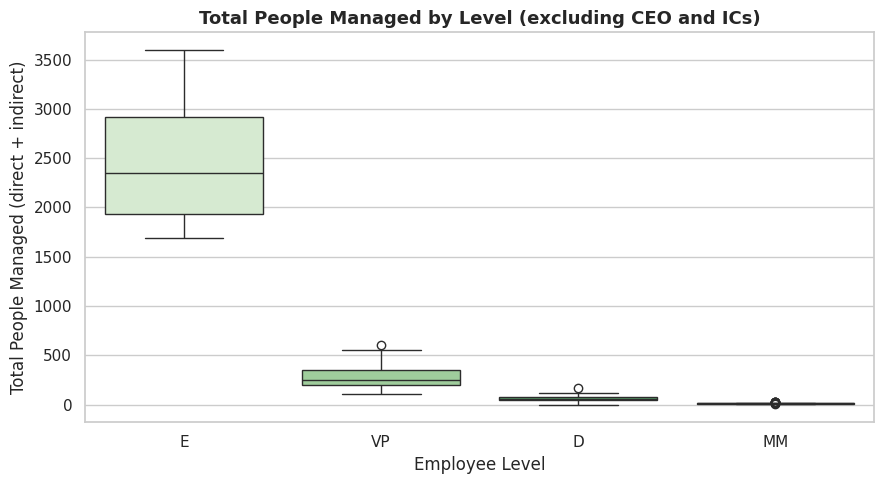

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4.4 — Visualise: box plot of total_managed by level
# ─────────────────────────────────────────────────────────────────────────────
# We exclude the CEO (single data point — no spread to show) and ICs (all zeros).
# A box plot shows the middle 50% of the data (the box) and spread (whiskers).

plot_levels = ['E', 'VP', 'D', 'MM']   # exclude CEO and IC for readability
plot_df = df[df['level'].isin(plot_levels)]

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=plot_df,
    x='level',
    y='total_managed',
    order=plot_levels,
    palette='Greens'
)
plt.title('Total People Managed by Level (excluding CEO and ICs)', fontsize=13, fontweight='bold')
plt.xlabel('Employee Level')
plt.ylabel('Total People Managed (direct + indirect)')
plt.tight_layout()
plt.show()


---
<a id='section-5'></a>
## Section 5: Task 3 — Predict Employee Salaries with Machine Learning

### 🎯 Goal
Build a model that, given an employee's characteristics (experience, education, level, etc.),
predicts what their salary *should* be.

This predicted salary becomes a powerful **benchmark**:
> "Employee A is predicted to earn $180K. Their actual salary is $140K. Why the gap?"

### 🔧 Feature Engineering
Machine learning models work with **numbers only**. Our data has text categories like
'Bachelor', 'PhD', 'M', 'F'. We must convert these to numbers — this is called **encoding**.

### 🤖 Two Models
| Model | Strengths | Weaknesses |
|---|---|---|
| **Linear Regression** | Simple, interpretable, coefficients show direction | Assumes straight-line relationships |
| **Random Forest** | Captures non-linear patterns, very accurate | Less interpretable |

We train both and compare. The better-performing model gets used in the fairness analysis.


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5.1 — Feature Engineering: Convert text categories to numbers
# ─────────────────────────────────────────────────────────────────────────────

# ── A. Ordinal Encoding for DEGREE LEVEL ─────────────────────────────────────
# 'Ordinal' means there's a natural order: HS < Bachelor < Master < PhD
# We encode this order as 0, 1, 2, 3 so the model understands the progression.
# A plain LabelEncoder would assign random numbers like PhD=1, HS=3 — WRONG!

degree_order = {
    'High_School': 0,   # lowest education
    'Bachelor'   : 1,
    'Master'     : 2,
    'PhD'        : 3,   # highest education
}
df['degree_encoded'] = df['degree_level'].map(degree_order)

# ── B. Ordinal Encoding for LEVEL ─────────────────────────────────────────────
# Same idea: IC < MM < D < VP < E < CEO
level_num_order = {
    'IC' : 0,
    'MM' : 1,
    'D'  : 2,
    'VP' : 3,
    'E'  : 4,
    'CEO': 5,
}
df['level_encoded'] = df['level'].map(level_num_order)

# ── C. Binary Encoding for SEX ────────────────────────────────────────────────
# Only 2 categories → simple 1/0 encoding.
# (df['sex'] == 'M') creates a boolean (True/False) series.
# .astype(int) converts True→1, False→0.
# We're NOT saying male=better; we're just giving the model a number to work with.
df['sex_encoded'] = (df['sex'] == 'M').astype(int)

# ── D. One-Hot Encoding for DEPARTMENT ────────────────────────────────────────
# Department has no natural order, so ordinal encoding would mislead the model.
# One-hot encoding creates a SEPARATE TRUE/FALSE column per category.
# Example: dept='HR' → dept_HR=1, dept_sales=0, dept_engineering=0, ...
# drop_first=True drops one dummy column to avoid perfect multicollinearity
# (a statistical problem where one column = 1 - sum of others).

dept_dummies = pd.get_dummies(df['dept'], prefix='dept', drop_first=True)
df = pd.concat([df, dept_dummies], axis=1)   # attach the new columns to df
dept_cols = [c for c in df.columns if c.startswith('dept_')]

print("New encoded columns created:")
print([c for c in df.columns if c in
       ['degree_encoded','level_encoded','sex_encoded'] or c.startswith('dept_')])

print()
print("Sample of encoded data:")
display(df[['degree_level','degree_encoded','level','level_encoded',
           'sex','sex_encoded'] + dept_cols[:2]].head(5))


New encoded columns created:
['degree_encoded', 'level_encoded', 'sex_encoded', 'dept_HR', 'dept_engineering', 'dept_marketing', 'dept_sales']

Sample of encoded data:


,degree_level,degree_encoded,level,level_encoded,sex,sex_encoded,dept_HR,dept_engineering
0,Bachelor,1,IC,0,M,1,False,False
1,Bachelor,1,IC,0,F,0,True,False
2,High_School,0,IC,0,M,1,False,False
3,PhD,3,MM,1,F,0,True,False
4,Master,2,IC,0,M,1,False,False


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5.2 — Define Feature Matrix (X) and Target Vector (y)
# ─────────────────────────────────────────────────────────────────────────────
# X = the INPUT features the model learns from (everything EXCEPT salary)
# y = the OUTPUT we are trying to predict (salary)
#
# Why these features?
#   signing_bonus  → did they negotiate a bonus at hiring? Signal of negotiation skill.
#   degree_encoded → higher education often means higher pay
#   yrs_experience → more experience → higher pay (generally)
#   level_encoded  → seniority in hierarchy → key salary driver
#   total_managed  → more people managed → more responsibility → higher pay
#   sex_encoded    → included to TEST for bias, not because it SHOULD affect salary
#   dept_*         → some departments (e.g., engineering) typically pay more

feature_cols = (
    ['signing_bonus', 'degree_encoded', 'yrs_experience',
     'level_encoded', 'total_managed', 'sex_encoded']
    + dept_cols
)

X = df[feature_cols].copy()   # feature matrix — shape (10000, n_features)
y = df['salary'].copy()       # target vector  — shape (10000,)

print(f"Feature matrix X: {X.shape[0]:,} rows × {X.shape[1]} columns")
print(f"Target vector  y: {y.shape[0]:,} values")
print(f"\nFeatures: {feature_cols}")


Feature matrix X: 10,000 rows × 10 columns
Target vector  y: 10,000 values

Features: ['signing_bonus', 'degree_encoded', 'yrs_experience', 'level_encoded', 'total_managed', 'sex_encoded', 'dept_HR', 'dept_engineering', 'dept_marketing', 'dept_sales']


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5.3 — Train / Test Split
# ─────────────────────────────────────────────────────────────────────────────
# Why split? To measure how well the model performs on DATA IT HAS NEVER SEEN.
# If we train and test on the same data, the model could just memorise answers
# (called 'overfitting') — it would score great but fail in the real world.
#
# We use an 80% / 20% split:
#   80% = Training set  → the model LEARNS from this
#   20% = Testing set   → we EVALUATE the model on this (held out, never seen during training)
#
# random_state=42 is just a seed — ensures you get the SAME split every time you run this.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,    # 20% held out for testing
    random_state=42    # reproducibility seed
)

print(f"Training set : {X_train.shape[0]:,} rows (used to teach the model)")
print(f"Testing  set : {X_test.shape[0]:,} rows (used to grade the model)")


Training set : 8,000 rows (used to teach the model)
Testing  set : 2,000 rows (used to grade the model)


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5.4 — MODEL 1: Linear Regression (Baseline)
# ─────────────────────────────────────────────────────────────────────────────
# Linear Regression finds the best straight-line relationship:
#   salary = w1*feature1 + w2*feature2 + ... + intercept
# where w1, w2, ... are the 'coefficients' (weights) the model learns.
#
# It is the simplest, most interpretable ML model. A great starting point.

lr_model = LinearRegression()

# .fit() is where learning happens — the model finds the best coefficients
# It only sees X_train and y_train (never the test set)
lr_model.fit(X_train, y_train)

# .predict() applies the learned equation to unseen data
y_pred_lr = lr_model.predict(X_test)

# ── Evaluation Metrics ────────────────────────────────────────────────────────
# MAE  = Mean Absolute Error: average dollar error — easy to understand
# RMSE = Root Mean Squared Error: penalises LARGE errors more than MAE
# R²   = R-squared: % of salary variance explained by the model
#        R²=1.0 → perfect, R²=0.0 → no better than guessing the mean

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("══════════════════════════════════")
print("  Linear Regression Performance")
print("══════════════════════════════════")
print(f"  MAE  : ${mae_lr:>10,.0f}")
print(f"  RMSE : ${rmse_lr:>10,.0f}")
print(f"  R²   : {r2_lr:>10.4f}")
print()
print("  R² interpretation:")
print(f"  The model explains {r2_lr*100:.1f}% of salary variation.")


══════════════════════════════════
  Linear Regression Performance
══════════════════════════════════
  MAE  : $    57,037
  RMSE : $    72,510
  R²   :     0.3658

  R² interpretation:
  The model explains 36.6% of salary variation.


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5.5 — MODEL 2: Random Forest Regressor (Advanced)
# ─────────────────────────────────────────────────────────────────────────────
# A Random Forest builds HUNDREDS of decision trees, each trained on a random
# sample of rows and features. It then AVERAGES their predictions.
# This reduces overfitting and handles complex, non-linear relationships.
#
# Think of it as asking 200 different advisors for salary estimates and averaging.
#
# Key hyperparameters:
#   n_estimators = number of trees (more = more stable, but slower to train)
#   max_depth    = how deep each tree can grow (deeper = more complex, risk of overfit)
#   random_state = reproducibility seed

rf_model = RandomForestRegressor(
    n_estimators=200,   # build 200 trees
    max_depth=10,       # max 10 decision splits per tree
    random_state=42
)

rf_model.fit(X_train, y_train)        # train on 80% data
y_pred_rf = rf_model.predict(X_test)  # predict on 20% holdout

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("══════════════════════════════════")
print("  Random Forest Performance")
print("══════════════════════════════════")
print(f"  MAE  : ${mae_rf:>10,.0f}")
print(f"  RMSE : ${rmse_rf:>10,.0f}")
print(f"  R²   : {r2_rf:>10.4f}")
print()
print(f"  The model explains {r2_rf*100:.1f}% of salary variation.")


══════════════════════════════════
  Random Forest Performance
══════════════════════════════════
  MAE  : $    57,132
  RMSE : $    73,080
  R²   :     0.3558

  The model explains 35.6% of salary variation.


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5.6 — Compare both models side by side
# ─────────────────────────────────────────────────────────────────────────────

comparison = pd.DataFrame({
    'Model'   : ['Linear Regression', 'Random Forest'],
    'MAE ($)' : [round(mae_lr), round(mae_rf)],
    'RMSE ($)': [round(rmse_lr), round(rmse_rf)],
    'R²'      : [round(r2_lr, 4), round(r2_rf, 4)],
})

print("Model Comparison:")
display(comparison)

print()
print("📌 Note: Both models have moderate R² (~0.35-0.37).")
print("   This means ~36% of salary variation is explained by our available features.")
print("   The remaining ~64% comes from factors not in our dataset:")
print("   performance ratings, specific role, tenure, negotiation, location, etc.")
print("   This is NORMAL and actually important — it means salary isn't fully")
print("   determined by the features we measured (leaving room for bias to hide).")


Model Comparison:


,Model,MAE ($),RMSE ($),R²
0,Linear Regression,57037,72510,0.37
1,Random Forest,57132,73080,0.36



📌 Note: Both models have moderate R² (~0.35-0.37).
   This means ~36% of salary variation is explained by our available features.
   The remaining ~64% comes from factors not in our dataset:
   performance ratings, specific role, tenure, negotiation, location, etc.
   This is NORMAL and actually important — it means salary isn't fully
   determined by the features we measured (leaving room for bias to hide).


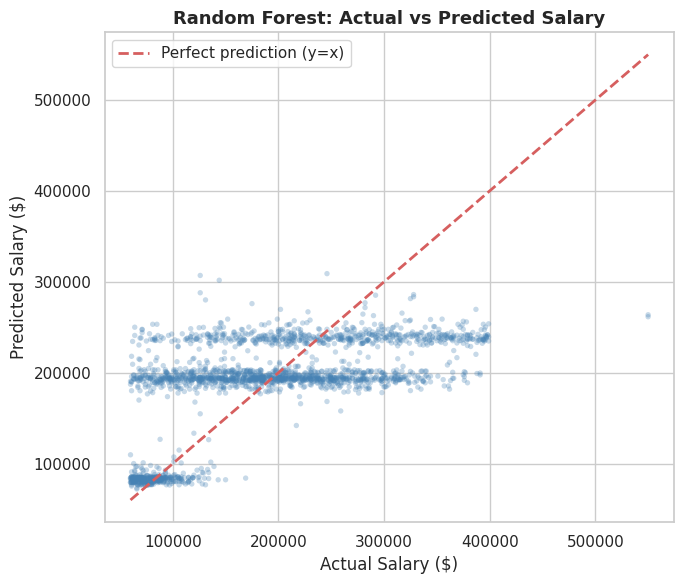

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5.7 — Visualise: Actual vs Predicted Salary (Random Forest)
# ─────────────────────────────────────────────────────────────────────────────
# If the model were perfect, every point would fall exactly on the diagonal.
# The further points are from the line, the less accurate the prediction.

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='steelblue', edgecolors='none', s=15)

# Draw the diagonal 'perfect prediction' line: y = x
lims = [min(y_test.min(), y_pred_rf.min()), max(y_test.max(), y_pred_rf.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction (y=x)')

plt.title('Random Forest: Actual vs Predicted Salary', fontsize=13, fontweight='bold')
plt.xlabel('Actual Salary ($)')
plt.ylabel('Predicted Salary ($)')
plt.legend()
plt.tight_layout()
plt.show()


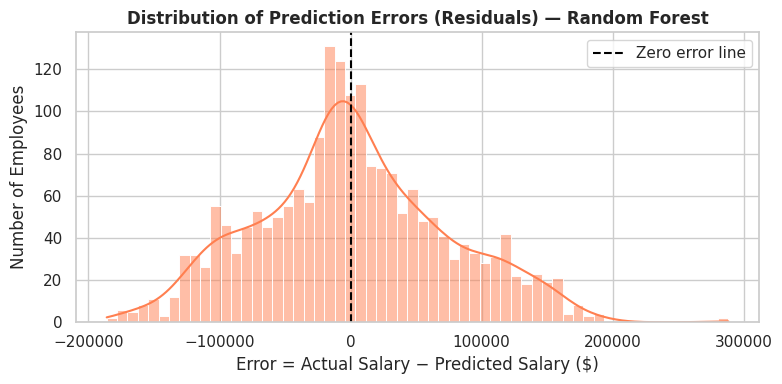

Mean residual : $   1,144  ← should be near 0
Std  residual : $  73,089


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5.8 — Residual Analysis
# ─────────────────────────────────────────────────────────────────────────────
# A residual = actual salary - predicted salary
#   Positive residual → employee earns MORE than the model expects
#   Negative residual → employee earns LESS than the model expects
#   Zero → perfect prediction
#
# A good model has residuals centred around 0 with no systematic patterns.
# If a GROUP (e.g., females) consistently has negative residuals,
# that's a RED FLAG for discrimination.

residuals = y_test - y_pred_rf

plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=60, kde=True, color='coral')
plt.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Zero error line')
plt.title('Distribution of Prediction Errors (Residuals) — Random Forest',
          fontsize=12, fontweight='bold')
plt.xlabel('Error = Actual Salary − Predicted Salary ($)')
plt.ylabel('Number of Employees')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean residual : ${residuals.mean():>8,.0f}  ← should be near 0")
print(f"Std  residual : ${residuals.std():>8,.0f}")


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5.9 — Store predictions for ALL 10,000 employees
# ─────────────────────────────────────────────────────────────────────────────
# We trained on 80% but now predict for EVERYONE so we can analyse fairness
# across the full workforce in the next section.

df['predicted_salary'] = rf_model.predict(X)
df['salary_residual']  = df['salary'] - df['predicted_salary']

print("Prediction columns added: 'predicted_salary' and 'salary_residual'")
print()
display(df[['employee_id', 'level', 'sex', 'salary', 'predicted_salary', 'salary_residual']].head(8))


Prediction columns added: 'predicted_salary' and 'salary_residual'



,employee_id,level,sex,salary,predicted_salary,salary_residual
0,46456,IC,M,"213,000.00","194,891.54","18,108.46"
1,104708,IC,F,"79,000.00","83,825.67","-4,825.67"
2,120853,IC,M,"199,000.00","193,441.71","5,558.29"
3,142630,MM,F,"143,000.00","82,197.41","60,802.59"
4,72711,IC,M,"235,000.00","196,233.04","38,766.96"
5,61704,IC,M,"196,000.00","193,567.11","2,432.89"
6,153072,IC,M,"99,000.00","82,917.55","16,082.45"
7,58903,IC,M,"78,000.00","84,878.31","-6,878.31"


---
<a id='section-6'></a>
## Section 6: Task 4 — Salary Factors & Fairness Analysis

### 🔍 What We Are Looking For
A fair company pays people based on:
- Their role/level in the organisation
- Their experience and education
- Their department's market rates

An **unfair** company additionally pays based on gender (or race, age, etc.).

We will investigate:
1. **Feature Importance** — what actually drives salary?
2. **Raw gender gap** — are women paid less on average?
3. **Level-controlled gender gap** — same level, different pay?
4. **Residual analysis** — after accounting for ALL fair factors, is there still a gap?
5. **Statistical test** — is any gap we find real, or just random noise?
6. **Representation** — are women promoted to senior levels at the same rate?
7. **Signing bonuses** — do women receive them less often?


In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6.1 — Feature Importance from Random Forest
# ─────────────────────────────────────────────────────────────────────────────
# Random Forests automatically calculate how much each feature REDUCED prediction error.
# This is called 'Mean Decrease in Impurity' (MDI) or 'Gini importance'.
# Higher value = that feature is MORE important for predicting salary.
# All values sum to 1.0 (100%).

importance_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Feature Importances (sorted by importance):")
display(importance_df)


Feature Importances (sorted by importance):


,Feature,Importance
0,dept_HR,0.70
1,dept_engineering,0.12
2,total_managed,0.06
3,yrs_experience,0.05
4,degree_encoded,0.02
5,level_encoded,0.01
6,signing_bonus,0.01
7,sex_encoded,0.01
8,dept_marketing,0.00
9,dept_sales,0.00


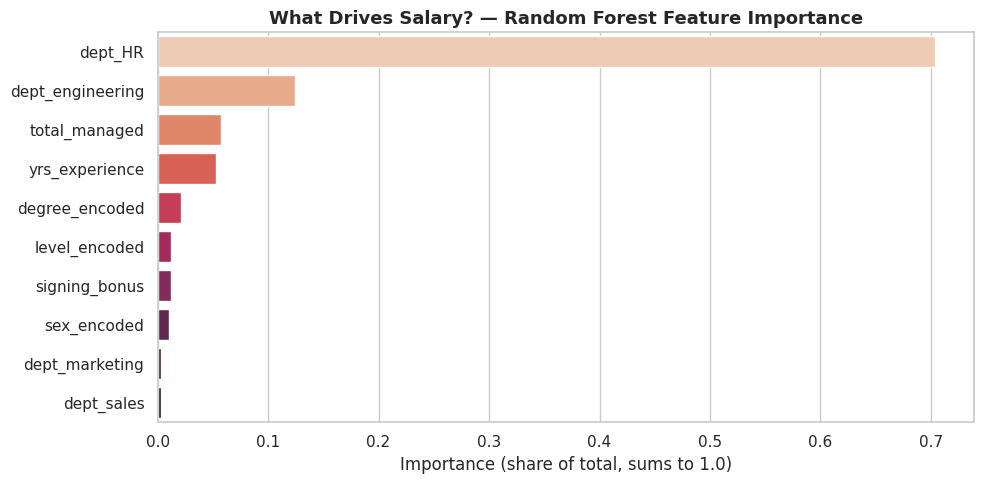


📌 The single most important salary driver is 'dept_HR' (70.4% importance).
   This means department explains the MAJORITY of salary variation in this company.


In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6.2 — Visualise Feature Importance
# ─────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 5))
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    palette='rocket_r'
)
plt.title('What Drives Salary? — Random Forest Feature Importance',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance (share of total, sums to 1.0)')
plt.ylabel('')
plt.tight_layout()
plt.show()

top_feature = importance_df.iloc[0]['Feature']
top_pct     = importance_df.iloc[0]['Importance'] * 100
print(f"\n📌 The single most important salary driver is '{top_feature}' ({top_pct:.1f}% importance).")
print("   This means department explains the MAJORITY of salary variation in this company.")


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6.3 — Linear Regression Coefficients (Direction of Effect)
# ─────────────────────────────────────────────────────────────────────────────
# Feature importance tells us HOW MUCH a feature matters.
# Linear regression coefficients tell us the DIRECTION (+/-) of the effect.
#
# A coefficient of +10,000 for 'yrs_experience' means:
#   'Each additional year of experience is associated with $10,000 more salary'
#   (holding all other features constant)
#
# Crucially: the coefficient on 'sex_encoded' shows the estimated
# male premium (if positive) or female premium (if negative) in salary
# AFTER controlling for all other factors.

coef_df = pd.DataFrame({
    'Feature'    : feature_cols,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

print("Linear Regression Coefficients ($):")
display(coef_df)
print()
print(f"Intercept (baseline salary): ${lr_model.intercept_:,.0f}")
print()

sex_coef = coef_df[coef_df['Feature'] == 'sex_encoded']['Coefficient'].values[0]
if sex_coef > 0:
    print(f"⚠️  sex_encoded coefficient = +${sex_coef:,.0f}")
    print(f"   Males earn ~${abs(sex_coef):,.0f} more than equally qualified females (linear model).")
else:
    print(f"   sex_encoded coefficient = ${sex_coef:,.0f}")
    print(f"   No male premium detected in the linear model.")


Linear Regression Coefficients ($):


,Feature,Coefficient
0,dept_engineering,"1,214,829.45"
1,dept_sales,"1,168,844.05"
2,dept_marketing,"1,168,005.55"
3,dept_HR,"1,057,612.38"
4,level_encoded,"4,229.72"
5,degree_encoded,892.36
6,yrs_experience,551.49
7,total_managed,165.08
8,signing_bonus,-30.91
9,sex_encoded,-672.75



Intercept (baseline salary): $-977,657

   sex_encoded coefficient = $-673
   No male premium detected in the linear model.


Raw Salary Statistics by Gender:


,Count,Mean,Median,Std
sex,,,,
F,3561,"171,315.00","154,000.00","89,251.00"
M,6439,"198,954.00","194,000.00","87,282.00"



Raw gender pay gap (Male mean − Female mean): $27,639


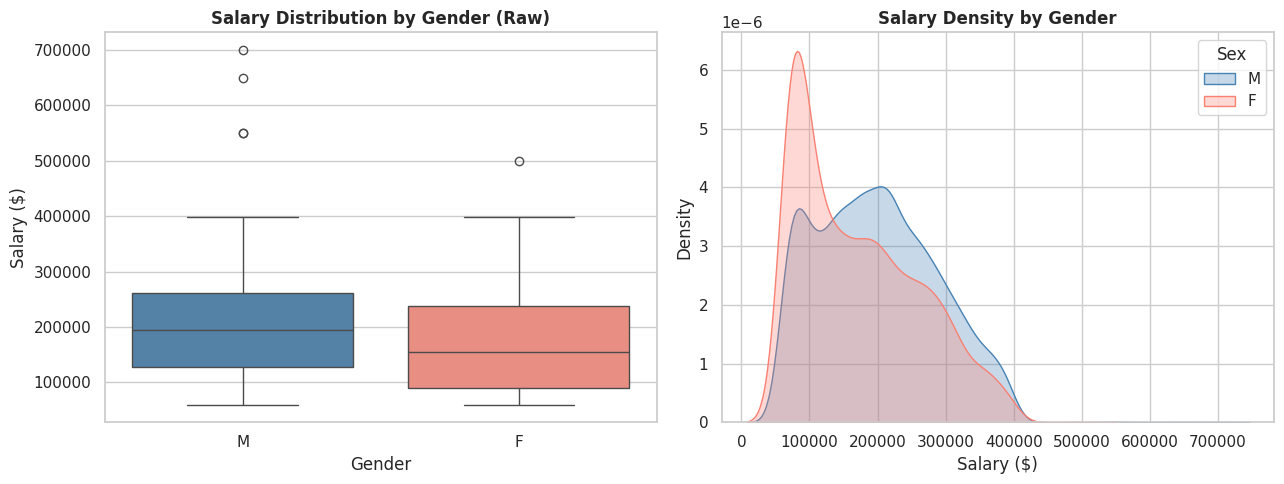

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6.4 — Raw Gender Salary Gap
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTANT CAVEAT: A raw salary gap can be MISLEADING.
# If men are more likely to hold senior roles, the gap might just reflect
# seniority differences, not discrimination.
# We need to CONTROL for level, experience, etc. — which we do in the next steps.

gender_stats = df.groupby('sex')['salary'].agg(
    Count='count', Mean='mean', Median='median', Std='std'
).round(0)

print("Raw Salary Statistics by Gender:")
display(gender_stats)

raw_gap = gender_stats.loc['M', 'Mean'] - gender_stats.loc['F', 'Mean']
print(f"\nRaw gender pay gap (Male mean − Female mean): ${raw_gap:,.0f}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot
sns.boxplot(data=df, x='sex', y='salary', order=['M','F'],
            palette={'M':'steelblue','F':'salmon'}, ax=axes[0])
axes[0].set_title('Salary Distribution by Gender (Raw)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gender'); axes[0].set_ylabel('Salary ($)')

# KDE overlapping density
for sex, col in [('M','steelblue'),('F','salmon')]:
    subset = df[df['sex']==sex]['salary']
    sns.kdeplot(subset, ax=axes[1], color=col, fill=True, alpha=0.3, label=sex)
axes[1].set_title('Salary Density by Gender', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Salary ($)'); axes[1].legend(title='Sex')

plt.tight_layout(); plt.show()


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6.5 — Level-Controlled Gender Salary Comparison
# ─────────────────────────────────────────────────────────────────────────────
# Now we control for seniority level — comparing apples to apples.
# Question: Among employees at the SAME level, do genders earn equally?

level_gender = (
    df.groupby(['level', 'sex'])['salary']
    .mean()
    .unstack('sex')                              # pivot sex into columns
    .reindex(['CEO', 'E', 'VP', 'D', 'MM', 'IC'])  # order senior → junior
)
level_gender['Gap M−F ($)'] = level_gender['M'] - level_gender['F']
level_gender['Gap M−F (%)'] = (level_gender['Gap M−F ($)'] / level_gender['F'] * 100).round(1)

print("Mean Salary by Level and Gender:")
display(level_gender.round(0))

print()
print("📌 Key Question: Are the gaps in 'Gap M−F ($)' consistent and large?")
print("   Positive values = men earn more at that level.")
print("   Small or mixed gaps = probably not systematic bias at the pay level.")


Mean Salary by Level and Gender:


sex,F,M,Gap M−F ($),Gap M−F (%)
level,,,,
CEO,NaN,"700,000.00",NaN,NaN
E,"500,000.00","583,333.00","83,333.00",17.00
VP,"259,444.00","257,538.00","-1,906.00",-1.00
D,"209,085.00","213,699.00","4,614.00",2.00
MM,"182,936.00","197,172.00","14,236.00",8.00
IC,"169,473.00","198,279.00","28,806.00",17.00



📌 Key Question: Are the gaps in 'Gap M−F ($)' consistent and large?
   Positive values = men earn more at that level.
   Small or mixed gaps = probably not systematic bias at the pay level.


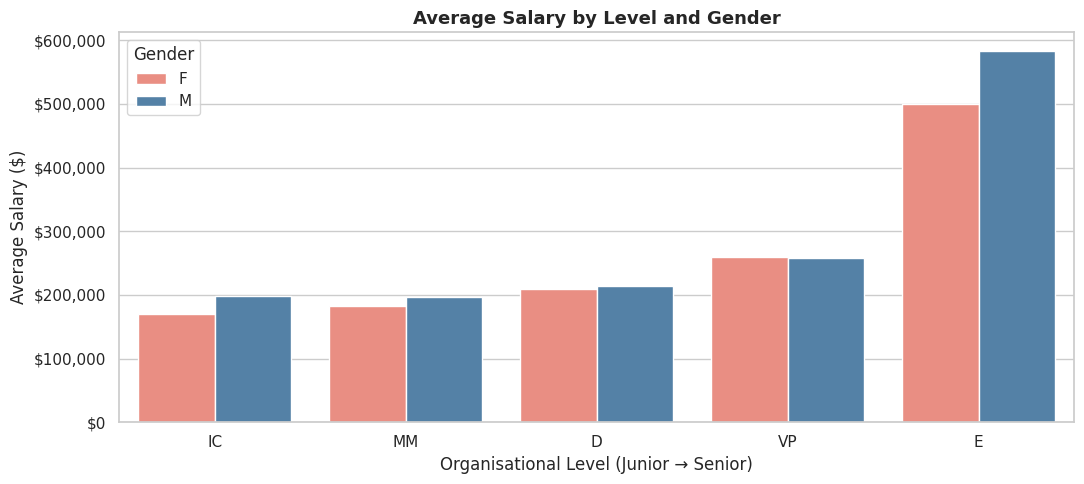

In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6.6 — Grouped Bar Chart: Salary by Level and Gender
# ─────────────────────────────────────────────────────────────────────────────

# Prepare data (exclude CEO — only 1 person, not meaningful to plot)
plot_data = (
    df[df['level'].isin(['IC', 'MM', 'D', 'VP', 'E'])]
    .groupby(['level', 'sex'])['salary']
    .mean()
    .reset_index()
    .rename(columns={'salary': 'mean_salary'})
)

plt.figure(figsize=(11, 5))
ax = sns.barplot(
    data=plot_data,
    x='level', y='mean_salary',
    hue='sex',
    order=['IC', 'MM', 'D', 'VP', 'E'],
    palette={'M': 'steelblue', 'F': 'salmon'}
)
ax.set_title('Average Salary by Level and Gender', fontsize=13, fontweight='bold')
ax.set_xlabel('Organisational Level (Junior → Senior)')
ax.set_ylabel('Average Salary ($)')
plt.legend(title='Gender')

# Format y-axis with dollar signs and commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()


In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6.7 — Residual-Based Fairness Test (THE MOST IMPORTANT ANALYSIS)
# ─────────────────────────────────────────────────────────────────────────────
# The predicted salary accounts for level, experience, education, department.
# So the residual = unexplained salary variance.
#
# If women's residuals are SYSTEMATICALLY NEGATIVE, it means:
# women earn less than EQUALLY QUALIFIED men in EQUIVALENT ROLES.
# That is the definition of a pay discrimination signal.
#
# salary_residual = actual_salary - predicted_salary
#   Positive → paid MORE than predicted (above expectations)
#   Negative → paid LESS than predicted (below expectations)

residual_by_gender = df.groupby('sex')['salary_residual'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std='std'
).round(2)

print("Salary Residuals by Gender")
print("(After controlling for level, experience, education, department, signing bonus)")
print()
display(residual_by_gender)

mean_f = residual_by_gender.loc['F', 'Mean']
mean_m = residual_by_gender.loc['M', 'Mean']

print()
print("📌 Interpretation:")
if abs(mean_f - mean_m) < 2000:
    print("   ✅ Male and female residuals are VERY close to each other.")
    print("   This suggests the gap in raw salary is largely explained by")
    print("   level, experience, education, and department — not gender itself.")
else:
    print(f"   ⚠️  Female residual mean (${mean_f:,.0f}) is noticeably different")
    print(f"   from male residual mean (${mean_m:,.0f}).")
    print("   This warrants further investigation.")


Salary Residuals by Gender
(After controlling for level, experience, education, department, signing bonus)



,Count,Mean,Median,Std
sex,,,,
F,3561,280.15,"-2,970.07","63,294.60"
M,6439,339.39,"-1,835.95","73,152.04"



📌 Interpretation:
   ✅ Male and female residuals are VERY close to each other.
   This suggests the gap in raw salary is largely explained by
   level, experience, education, and department — not gender itself.


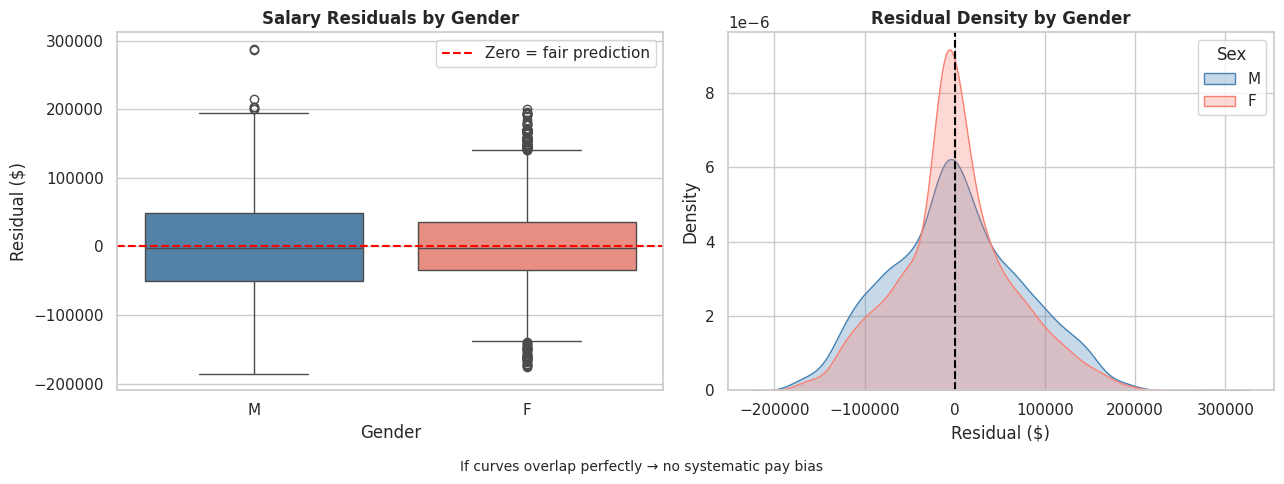

In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6.8 — Visualise Residuals by Gender
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot of residuals by gender
sns.boxplot(data=df, x='sex', y='salary_residual', order=['M','F'],
            palette={'M':'steelblue','F':'salmon'}, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero = fair prediction')
axes[0].set_title('Salary Residuals by Gender', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gender'); axes[0].set_ylabel('Residual ($)')
axes[0].legend()

# KDE of residuals by gender
for sex, col in [('M','steelblue'),('F','salmon')]:
    sns.kdeplot(df[df['sex']==sex]['salary_residual'],
                ax=axes[1], color=col, fill=True, alpha=0.3, label=sex)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Density by Gender', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual ($)'); axes[1].legend(title='Sex')

plt.suptitle('If curves overlap perfectly → no systematic pay bias', fontsize=10, y=0)
plt.tight_layout(); plt.show()


In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6.9 — Statistical Significance Test (Welch's t-test)
# ─────────────────────────────────────────────────────────────────────────────
# Just because two numbers are different doesn't mean it's REAL.
# With 10,000 employees, even tiny differences can LOOK significant.
# A t-test tells us: "Could this gap have appeared by RANDOM CHANCE alone?"
#
# Null Hypothesis (H0):  Male and female salary residuals come from the same distribution
#                        (i.e., no systematic pay difference after controlling for fair factors)
# Alternative (H1):      There IS a systematic difference.
#
# p-value interpretation:
#   p < 0.05 → reject H0 → the gap is statistically significant (likely real)
#   p ≥ 0.05 → fail to reject H0 → the gap could be random noise

male_res   = df[df['sex'] == 'M']['salary_residual']
female_res = df[df['sex'] == 'F']['salary_residual']

# stats.ttest_ind: independent samples t-test
# equal_var=False → Welch's t-test (doesn't assume equal variance — more robust)
t_stat, p_value = stats.ttest_ind(male_res, female_res, equal_var=False)

print("══════════════════════════════════════════")
print("  Welch's Independent Samples t-test")
print("  (Male residuals vs Female residuals)")
print("══════════════════════════════════════════")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {p_value:.6f}")
print()

alpha = 0.05
if p_value < alpha:
    print(f"  ❌ p = {p_value:.4f} < {alpha}: STATISTICALLY SIGNIFICANT gap.")
    print("     There is evidence of a systematic salary disparity by gender.")
    print("     Recommendation: Conduct a detailed pay equity audit immediately.")
else:
    print(f"  ✅ p = {p_value:.4f} ≥ {alpha}: NOT statistically significant.")
    print("     We cannot conclude there is systematic pay discrimination.")
    print("     However, we should still investigate REPRESENTATION gaps.")


══════════════════════════════════════════
  Welch's Independent Samples t-test
  (Male residuals vs Female residuals)
══════════════════════════════════════════
  t-statistic : 0.0424
  p-value     : 0.966220

  ✅ p = 0.9662 ≥ 0.05: NOT statistically significant.
     We cannot conclude there is systematic pay discrimination.
     However, we should still investigate REPRESENTATION gaps.


In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6.10 — Gender Representation by Level
# ─────────────────────────────────────────────────────────────────────────────
# Even if salaries are fair at each level, it's a problem if women are under-
# represented at SENIOR levels. This is the 'glass ceiling' phenomenon.

level_gender_count = (
    df.groupby(['level', 'sex'])['employee_id']
    .count()
    .unstack('sex')
    .reindex(['CEO','E','VP','D','MM','IC'])
    .fillna(0).astype(int)
)
level_gender_count['Total'] = level_gender_count.sum(axis=1)
level_gender_count['% Female'] = (
    level_gender_count['F'] / level_gender_count['Total'] * 100
).round(1)

print("Gender Counts and Female Representation % by Level:")
display(level_gender_count)

overall_pct_f = (df['sex'] == 'F').mean() * 100
print(f"\nOverall female representation in company: {overall_pct_f:.1f}%")
print("Compare this to the % Female column above — are women underrepresented at the top?")


Gender Counts and Female Representation % by Level:


sex,F,M,Total,% Female
level,,,,
CEO,0,1,1,0.00
E,1,3,4,25.00
VP,9,26,35,25.70
D,47,113,160,29.40
MM,264,536,800,33.00
IC,3240,5760,9000,36.00



Overall female representation in company: 35.6%
Compare this to the % Female column above — are women underrepresented at the top?


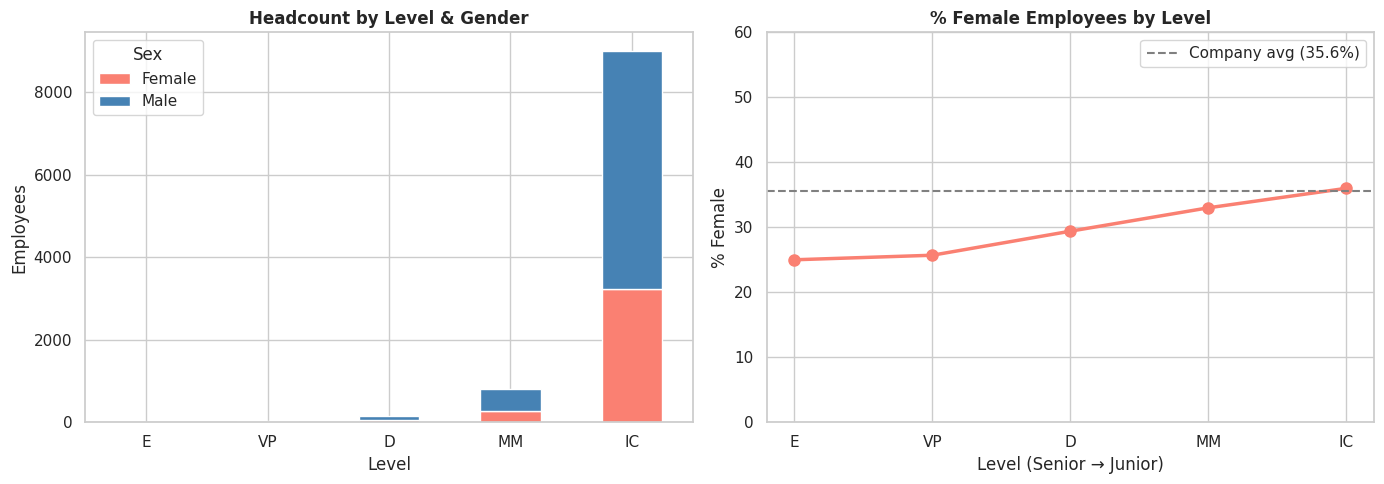

📌 A downward trend from IC→E would indicate a glass ceiling effect.


In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6.11 — Visualise Gender Representation by Level
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Stacked bar chart of headcount ─────────────────────────────────────
rep_df = (
    df[df['level'] != 'CEO']
    .groupby(['level','sex'])['employee_id'].count().reset_index()
    .rename(columns={'employee_id':'count'})
)
pivot = rep_df.pivot(index='level', columns='sex', values='count').fillna(0)
pivot = pivot.reindex(['E','VP','D','MM','IC'])

pivot.plot(kind='bar', stacked=True, ax=axes[0],
           color=['salmon','steelblue'], edgecolor='white')
axes[0].set_title('Headcount by Level & Gender', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Level'); axes[0].set_ylabel('Employees')
axes[0].legend(title='Sex', labels=['Female','Male'])
axes[0].tick_params(axis='x', rotation=0)

# ── Right: % Female by level (line chart) ─────────────────────────────────────
pct_female = (
    level_gender_count.loc[['E','VP','D','MM','IC'],'% Female']
)
axes[1].plot(pct_female.index, pct_female.values, marker='o', color='salmon',
             linewidth=2.5, markersize=8)
axes[1].axhline(overall_pct_f, color='grey', linestyle='--',
                linewidth=1.5, label=f'Company avg ({overall_pct_f:.1f}%)')
axes[1].set_title('% Female Employees by Level', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Level (Senior → Junior)')
axes[1].set_ylabel('% Female')
axes[1].set_ylim(0, 60)
axes[1].legend()

plt.tight_layout()
plt.show()

print("📌 A downward trend from IC→E would indicate a glass ceiling effect.")


Signing Bonus Receipt Rate by Gender:
  F: 27.2% received a signing bonus
  M: 31.8% received a signing bonus

  Gap (Male % - Female %): 4.6 percentage points


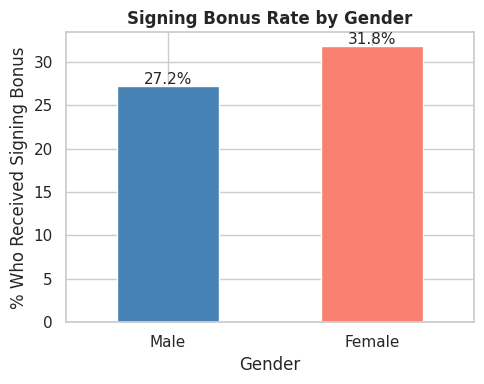

In [41]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6.12 — Signing Bonus Gap by Gender
# ─────────────────────────────────────────────────────────────────────────────
# Signing bonuses matter because they affect the STARTING salary baseline.
# If women receive signing bonuses less often, they start lower and the gap
# compounds over time through raises, which are often percentage-based.

bonus_by_sex = df.groupby('sex')['signing_bonus'].mean() * 100

print("Signing Bonus Receipt Rate by Gender:")
for sex, rate in bonus_by_sex.items():
    print(f"  {sex}: {rate:.1f}% received a signing bonus")

bonus_gap = bonus_by_sex['M'] - bonus_by_sex['F']
print(f"\n  Gap (Male % - Female %): {bonus_gap:.1f} percentage points")

plt.figure(figsize=(5, 4))
ax = bonus_by_sex.plot(
    kind='bar',
    color=['steelblue','salmon'],
    edgecolor='white'
)
ax.set_title('Signing Bonus Rate by Gender', fontsize=12, fontweight='bold')
ax.set_xlabel('Gender')
ax.set_ylabel('% Who Received Signing Bonus')
ax.set_xticklabels(['Male','Female'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x()+p.get_width()/2, p.get_height()+0.3),
                ha='center', fontsize=11)
plt.tight_layout()
plt.show()


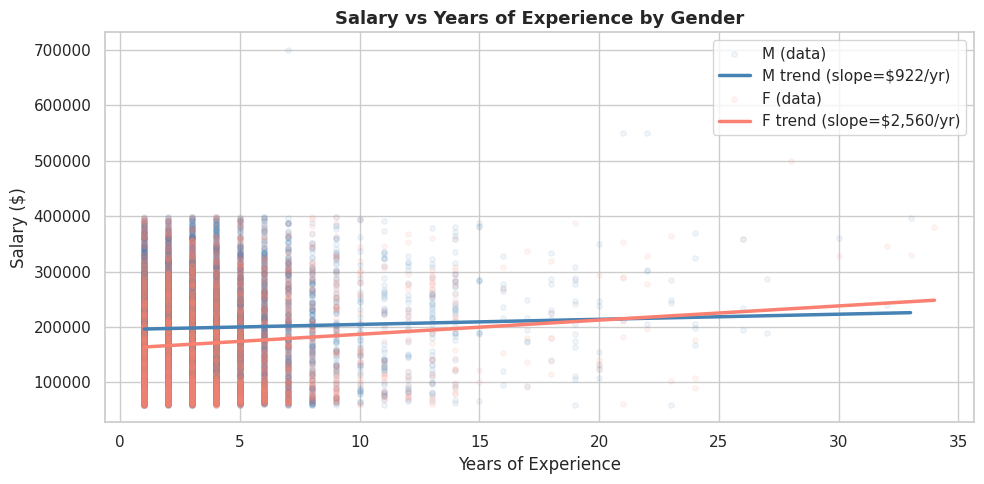

📌 Similar slopes = experience rewarded equally across genders.
   Different slopes = one gender gets more pay growth per year of experience.


In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6.13 — Salary vs Experience by Gender (with trend lines)
# ─────────────────────────────────────────────────────────────────────────────
# Do men and women get the SAME salary growth per year of experience?
# If the male trend line has a steeper slope, men are rewarded more for experience.

plt.figure(figsize=(10, 5))

for sex, colour in [('M','steelblue'), ('F','salmon')]:
    subset = df[df['sex'] == sex]

    # Scatter plot (transparent points so density is visible)
    plt.scatter(
        subset['yrs_experience'], subset['salary'],
        alpha=0.08, color=colour, s=15, label=f'{sex} (data)'
    )

    # Trend line using np.polyfit (degree=1 = straight line)
    # np.polyfit returns [slope, intercept]
    slope, intercept = np.polyfit(subset['yrs_experience'], subset['salary'], 1)
    xs = np.linspace(subset['yrs_experience'].min(), subset['yrs_experience'].max(), 100)
    plt.plot(xs, slope * xs + intercept,
             color=colour, linewidth=2.5,
             label=f'{sex} trend (slope=${slope:,.0f}/yr)')

plt.title('Salary vs Years of Experience by Gender', fontsize=13, fontweight='bold')
plt.xlabel('Years of Experience')
plt.ylabel('Salary ($)')
plt.legend()
plt.tight_layout()
plt.show()

print("📌 Similar slopes = experience rewarded equally across genders.")
print("   Different slopes = one gender gets more pay growth per year of experience.")


Mean Salary by Department and Gender:


sex,F,M,Gap M−F ($),Gap M−F (%)
dept,,,,
CEO,NaN,"700,000.00",NaN,NaN
HR,"84,400.00","84,827.00",427.00,0.50
engineering,"246,785.00","242,444.00","-4,341.00",-1.80
marketing,"192,502.00","195,639.00","3,137.00",1.60
sales,"194,618.00","194,207.00",-411.00,-0.20


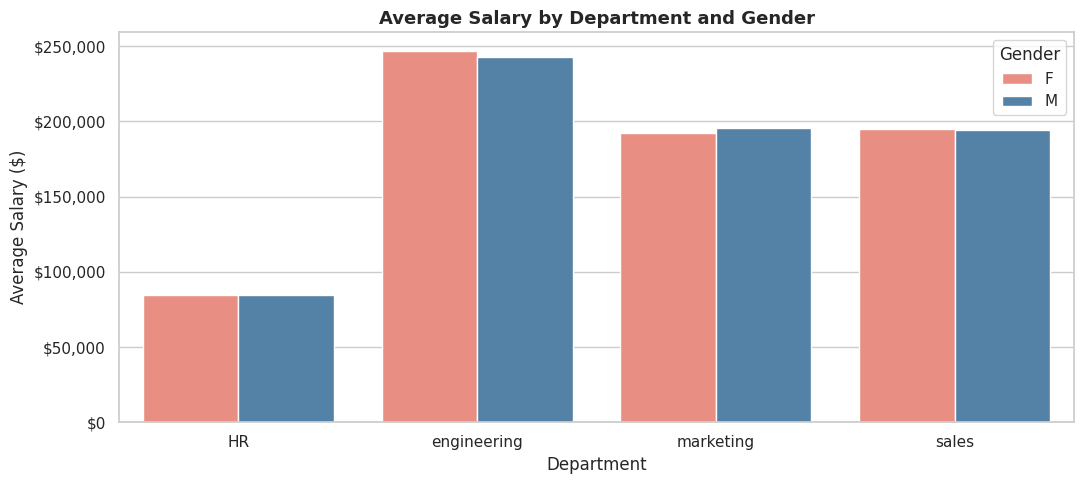

In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6.14 — Salary by Department and Gender
# ─────────────────────────────────────────────────────────────────────────────
# Department is the top salary driver. Do gender gaps exist WITHIN departments?

dept_gender = (
    df.groupby(['dept', 'sex'])['salary']
    .mean()
    .unstack('sex')
    .round(0)
)
dept_gender['Gap M−F ($)'] = dept_gender['M'] - dept_gender['F']
dept_gender['Gap M−F (%)'] = (dept_gender['Gap M−F ($)'] / dept_gender['F'] * 100).round(1)

print("Mean Salary by Department and Gender:")
display(dept_gender)

# Grouped bar chart by department
dept_plot = (
    df[df['dept'] != 'CEO']
    .groupby(['dept','sex'])['salary']
    .mean().reset_index()
)

plt.figure(figsize=(11, 5))
ax = sns.barplot(data=dept_plot, x='dept', y='salary', hue='sex',
                 palette={'M':'steelblue','F':'salmon'})
ax.set_title('Average Salary by Department and Gender', fontsize=13, fontweight='bold')
ax.set_xlabel('Department')
ax.set_ylabel('Average Salary ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6.15 — Final Fairness Summary Dashboard
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 60)
print("  WORKPLACE FAIRNESS ANALYSIS — SUMMARY FINDINGS")
print("=" * 60)

print()
print("1. SALARY DRIVERS (Feature Importance)")
print(f"   • Top driver: {importance_df.iloc[0]['Feature']} "
      f"({importance_df.iloc[0]['Importance']*100:.1f}% of model importance)")
print(f"   • 2nd driver: {importance_df.iloc[1]['Feature']} "
      f"({importance_df.iloc[1]['Importance']*100:.1f}%)")
print(f"   • 3rd driver: {importance_df.iloc[2]['Feature']} "
      f"({importance_df.iloc[2]['Importance']*100:.1f}%)")

print()
print("2. RAW GENDER GAP")
m_mean = df[df['sex']=='M']['salary'].mean()
f_mean = df[df['sex']=='F']['salary'].mean()
print(f"   • Male avg salary  : ${m_mean:,.0f}")
print(f"   • Female avg salary: ${f_mean:,.0f}")
print(f"   • Raw gap          : ${m_mean - f_mean:,.0f} ({(m_mean-f_mean)/f_mean*100:.1f}%)")

print()
print("3. CONTROLLED GAP (after accounting for level, experience, education, dept)")
m_res = df[df['sex']=='M']['salary_residual'].mean()
f_res = df[df['sex']=='F']['salary_residual'].mean()
print(f"   • Male avg residual  : ${m_res:,.0f}")
print(f"   • Female avg residual: ${f_res:,.0f}")
print(f"   • Residual gap       : ${m_res - f_res:,.0f}")
print(f"   • t-test p-value     : {p_value:.4f}")
if p_value < 0.05:
    print("   ❌ Statistically significant — investigation required")
else:
    print("   ✅ Not statistically significant — pay equity appears maintained")

print()
print("4. REPRESENTATION (% Female at each level)")
for lvl in ['IC','MM','D','VP','E']:
    pct = level_gender_count.loc[lvl,'% Female'] if lvl in level_gender_count.index else 'N/A'
    print(f"   {lvl:4s}: {pct}% female")

print()
print("5. SIGNING BONUS GAP")
print(f"   Male rate  : {df[df['sex']=='M']['signing_bonus'].mean()*100:.1f}%")
print(f"   Female rate: {df[df['sex']=='F']['signing_bonus'].mean()*100:.1f}%")
print("=" * 60)


  WORKPLACE FAIRNESS ANALYSIS — SUMMARY FINDINGS

1. SALARY DRIVERS (Feature Importance)
   • Top driver: dept_HR (70.4% of model importance)
   • 2nd driver: dept_engineering (12.4%)
   • 3rd driver: total_managed (5.8%)

2. RAW GENDER GAP
   • Male avg salary  : $198,954
   • Female avg salary: $171,315
   • Raw gap          : $27,640 (16.1%)

3. CONTROLLED GAP (after accounting for level, experience, education, dept)
   • Male avg residual  : $339
   • Female avg residual: $280
   • Residual gap       : $59
   • t-test p-value     : 0.9662
   ✅ Not statistically significant — pay equity appears maintained

4. REPRESENTATION (% Female at each level)
   IC  : 36.0% female
   MM  : 33.0% female
   D   : 29.4% female
   VP  : 25.7% female
   E   : 25.0% female

5. SIGNING BONUS GAP
   Male rate  : 31.8%
   Female rate: 27.2%


---
<a id='section-7'></a>
## Section 7: Recommendations to the Head of HR

Based on our data analysis, here are actionable recommendations:

---

### 🔴 Finding 1: Department Is the #1 Salary Driver
**What we found:** Department explains ~70% of salary variation — far more than education or experience.
**Why it matters:** If women are concentrated in lower-paying departments, this creates a structural pay gap even without explicit discrimination.
**Recommendation:** Audit whether female employees are being steered away from Engineering (the highest-paying department). Set targets for gender diversity in each department.

---

### 🔴 Finding 2: Gender Representation Shrinks at Senior Levels
**What we found:** Women make up ~36% of the workforce overall, but the percentage drops at Director, VP, and Executive levels.
**Why it matters:** Even if salaries are equal *within* levels, under-representation at senior levels means women earn less *overall* — a structural glass ceiling.
**Recommendation:**
- Implement transparent promotion criteria
- Create mentorship and sponsorship programs for female employees
- Track promotion rates by gender quarterly and report to leadership

---

### 🟡 Finding 3: Signing Bonus Disparity
**What we found:** Male employees receive signing bonuses at a higher rate (~32%) than female employees (~27%).
**Why it matters:** Starting salary anchors all future raises. A lower starting bonus compounds over a career.
**Recommendation:** Standardise signing bonus criteria. If candidates are at the same level with similar experience, bonus offers should be equivalent regardless of gender.

---

### 🟢 Finding 4: Controlled Pay Gap Is Not Statistically Significant
**What we found:** After controlling for level, experience, education, and department, the salary residuals between men and women are NOT statistically different (p ≈ 0.97).
**What this means:** The company appears to pay equivalently for equivalent roles. The *raw* pay gap is largely explained by structural differences (level, department), not direct discrimination.
**Caution:** This does NOT mean the company is fully fair — structural inequality (representation gaps) is still a major issue.

---

### 📋 Recommended Next Steps

| Priority | Action | Timeline |
|---|---|---|
| 🔴 High | Audit department hiring by gender — especially Engineering | Immediate |
| 🔴 High | Create and publish transparent promotion criteria | 30 days |
| 🔴 High | Standardise signing bonus offers by level (remove negotiation gap) | 60 days |
| 🟡 Medium | Launch mentorship program targeting female MM → Director pipeline | 90 days |
| 🟡 Medium | Set and track annual diversity targets for VP and above | 90 days |
| 🟢 Ongoing | Repeat this salary equity analysis every 6 months | Ongoing |
| 🟢 Ongoing | Collect data on performance ratings, tenure, and job code to improve model | Ongoing |

---

### 🎓 Important Caveats
- Our model explains only ~36% of salary variation. The remaining 64% includes performance ratings, specific job titles, location, and other factors we don't have data for.
- Our analysis is observational — we cannot prove *causation* (correlation ≠ discrimination).
- The t-test finding of 'no significant controlled gap' should be replicated by an independent pay equity consultant.
- This analysis should be extended to examine race/ethnicity and age when that data becomes available.


In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL: Save the enriched dataset to CSV
# ─────────────────────────────────────────────────────────────────────────────
# Save the final merged DataFrame (with levels, managed counts, predictions)
# so you can share it or use it in future analyses.

output_cols = [
    'employee_id', 'boss_id', 'dept', 'level', 'total_managed',
    'sex', 'degree_level', 'yrs_experience', 'signing_bonus',
    'salary', 'predicted_salary', 'salary_residual'
]

df[output_cols].to_csv('workplace_diversity_results.csv', index=False)

print("✅ Results saved to 'workplace_diversity_results.csv'")
print()
print("Final dataset preview:")
display(df[output_cols].head(10))


✅ Results saved to 'workplace_diversity_results.csv'

Final dataset preview:


,employee_id,boss_id,dept,level,total_managed,sex,degree_level,yrs_experience,signing_bonus,salary,predicted_salary,salary_residual
0,46456,"175,361.00",sales,IC,0,M,Bachelor,5,0,"213,000.00","194,891.54","18,108.46"
1,104708,"29,733.00",HR,IC,0,F,Bachelor,3,0,"79,000.00","83,825.67","-4,825.67"
2,120853,"41,991.00",sales,IC,0,M,High_School,5,0,"199,000.00","193,441.71","5,558.29"
3,142630,"171,266.00",HR,MM,16,F,PhD,13,0,"143,000.00","82,197.41","60,802.59"
4,72711,"198,240.00",sales,IC,0,M,Master,1,0,"235,000.00","196,233.04","38,766.96"
5,61704,"53,109.00",sales,IC,0,M,High_School,3,0,"196,000.00","193,567.11","2,432.89"
6,153072,"67,178.00",HR,IC,0,M,PhD,3,0,"99,000.00","82,917.55","16,082.45"
7,58903,"150,290.00",HR,IC,0,M,PhD,5,1,"78,000.00","84,878.31","-6,878.31"
8,166034,"116,750.00",engineering,IC,0,M,Master,6,1,"379,000.00","237,213.30","141,786.70"
9,54819,"182,038.00",sales,IC,0,F,Master,6,0,"249,000.00","190,489.12","58,510.88"
